# 03 — Групповая относительная оптимизация политики (GRPO)

**Этап 3 задания на ВКР:** дообучение лучших SFT-моделей методом GRPO.

Шаги:

0. Зависимости, GPU, пути, импорты
1. Загрузка SFT-результатов, выбор лучшей модели по val_loss
2. Слияние SFT-адаптера с базовой моделью
3. Подготовка данных для GRPO (промпты + золотые ответы)
4. Reward-функция, конфигурация GRPO, функция обучения
5. Функция оценки контрольных точек (vLLM + кэш)
6. Smoke test (v500_best, 100 шагов)
7. ═══ MIN ═══ Полный прогон: обучение (4 модели)
8. ═══ MIN ═══ Оценка всех контрольных точек
9. Сводная таблица

## Шаг 0. Зависимости, GPU, пути, импорты

In [1]:
import torch, os, json, sys, time, re, logging, gc, shutil
import numpy as np

assert torch.cuda.is_available(), 'GPU не найден'
print(f'GPU: {torch.cuda.get_device_name(0)}, '
      f'{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
drive.mount('/content/drive')

# Пути (те же, что в 00–02)
MODEL_ROOT    = '/content/drive/MyDrive/vkr_models'
DATA_ROOT     = '/content/drive/MyDrive/vkr_data'
RESULTS_ROOT  = '/content/drive/MyDrive/vkr_results'
SUBSETS_DIR   = f'{DATA_ROOT}/subsets'
BASE_MODEL    = f'{MODEL_ROOT}/Qwen2.5-1.5B'

# Из 02_sft
SFT_MODELS    = f'{MODEL_ROOT}/sft'
SFT_RESULTS   = f'{RESULTS_ROOT}/sft'

# Новые пути
MERGED_DIR    = f'{MODEL_ROOT}/sft_merged'
GRPO_MODELS   = f'{MODEL_ROOT}/grpo'
GRPO_RESULTS  = f'{RESULTS_ROOT}/grpo'
GRPO_GENS     = f'{RESULTS_ROOT}/grpo/generations'
for d in [MERGED_DIR, GRPO_MODELS, GRPO_RESULTS, GRPO_GENS]:
    os.makedirs(d, exist_ok=True)

assert os.path.exists(BASE_MODEL), f'Модель не найдена: {BASE_MODEL}'

# parsing.py из 00_setup
sys.path.insert(0, DATA_ROOT)
import parsing

# Attention backend
try:
    import flash_attn; ATTN_IMPL = 'flash_attention_2'
except ImportError:
    ATTN_IMPL = 'eager'

print(f'Базовая модель: {BASE_MODEL}')
print(f'Attention:      {ATTN_IMPL}')

GPU: NVIDIA A100-SXM4-80GB, 85.1 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Базовая модель: /content/drive/MyDrive/vkr_models/Qwen2.5-1.5B
Attention:      eager


## Шаг 1. Загрузка SFT-результатов, выбор лучших моделей

Для каждого объёма данных (500, 1000, 2000, 5000) выбираем SFT-модель с наименьшим val_loss.
Выбор по val_loss, а не по тестовой accuracy — чтобы избежать утечки тестовых данных в выбор модели.


Токенизатор — тот же от базовой модели. Один на весь пайплайн (base → SFT → merged → GRPO), vocab не меняется.

Тестовые наборы — GSM8K (1319 задач) и MATH-500 (500 задач) скачиваются из HuggingFace. Из них предвычисляются два массива: PROBLEMS (тексты задач) и GOLDS (правильные ответы). Предвычисление здесь, а не при каждом eval — чтобы не парсить 1819 ответов по 40+ раз (по одному разу на каждый GRPO-чекпоинт). Код дословно из 02_sft.

Константы эксперимента — THRESHOLDS, VOLUMES, SEEDS, PROMPT_SUFFIX. Тоже из 02_sft. Определяют пространство поиска: 3 порога длины CoT × 4 объёма данных × 3 seed = 36 SFT-прогонов, из которых GRPO выберет 4 лучших (по одному на volume).


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, PeftModel
from datasets import load_dataset, load_from_disk

logging.getLogger('transformers.generation').setLevel(logging.ERROR)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f'Токенизатор: vocab={tokenizer.vocab_size}, EOS={tokenizer.eos_token!r}')

# Тестовые наборы (для eval после GRPO)
ds_gsm8k = load_dataset('openai/gsm8k', 'main', split='test')
ds_math500 = load_dataset('HuggingFaceH4/MATH-500', split='test')
assert len(ds_gsm8k) == 1319 and len(ds_math500) == 500
print(f'GSM8K: {len(ds_gsm8k)}, MATH-500: {len(ds_math500)}')

GSM8K_PROBLEMS = [ex['question'] for ex in ds_gsm8k]
GSM8K_GOLDS    = [parsing.extract_answer_gsm8k(ex['answer']) for ex in ds_gsm8k]
MATH_PROBLEMS  = [ex['problem'] for ex in ds_math500]
MATH_GOLDS     = [ex['answer'] for ex in ds_math500]

THRESHOLDS = [2048, 4096, 8192]
VOLUMES    = [500, 1000, 2000, 5000]
SEEDS      = [42, 43, 44]

PROMPT_SUFFIX = '\n\nPlease reason step by step, and put your final answer within \\boxed{}.'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Токенизатор: vocab=151643, EOS='<|endoftext|>'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


GSM8K: 1319, MATH-500: 500


выбор SFT-моделей для GRPO.

1 - загрузка JSON-результатов всех SFT-прогонов из SFT_RESULTS. Каждый JSON содержит train.final_val_loss, gsm8k.accuracy, math500.accuracy. Сейчас загрузится 1 из 36 (только smoke test c2048_v500_s42). После полного прогона 02_sft — все 36.

2 - select_best_sft(volume). Для каждого объёма (500, 1000, 2000, 5000) перебирает все комбинации (threshold, seed), собирает кандидатов, выбирает с минимальным final_val_loss. Почему val_loss, а не accuracy на тесте — чтобы тестовые данные не участвовали в выборе модели (data leakage, зафиксировано в отчёте batch 2).
assert best_sft — если ни одного SFT-результата нет, падаем с сооб

In [3]:
# Загрузка всех SFT-результатов
sft_results = {}
for t in THRESHOLDS:
    for v in VOLUMES:
        for s in SEEDS:
            name = f'c{t}_v{v}_s{s}'
            path = f'{SFT_RESULTS}/{name}.json'
            if os.path.exists(path):
                with open(path) as f:
                    sft_results[name] = json.load(f)

print(f'SFT-результатов загружено: {len(sft_results)}/{len(THRESHOLDS)*len(VOLUMES)*len(SEEDS)}')

# Выбор лучшей модели для каждого объёма по val_loss
def select_best_sft(volume: int) -> dict:
    """Среди всех (threshold, seed) для данного volume —
    выбрать модель с наименьшим final_val_loss."""
    candidates = []
    for t in THRESHOLDS:
        for s in SEEDS:
            name = f'c{t}_v{volume}_s{s}'
            if name not in sft_results:
                continue
            r = sft_results[name]
            vl = r.get('train', {}).get('final_val_loss')
            if vl is not None and not np.isnan(vl):
                candidates.append({
                    'run_name': name,
                    'subset': f'c{t}_v{volume}',
                    'threshold': t, 'volume': volume, 'seed': s,
                    'val_loss': vl,
                    'gsm8k_acc': r.get('gsm8k', {}).get('accuracy'),
                    'math500_acc': r.get('math500', {}).get('accuracy'),
                })
    if not candidates:
        return None
    return min(candidates, key=lambda x: x['val_loss'])

best_sft = {}
for v in VOLUMES:
    b = select_best_sft(v)
    if b:
        best_sft[v] = b
        print(f'v{v}: {b["run_name"]}  val_loss={b["val_loss"]:.4f}  '
              f'GSM8K={b["gsm8k_acc"]:.3f}  MATH={b["math500_acc"]:.3f}')
    else:
        print(f'v{v}: нет готовых SFT-результатов')

assert best_sft, 'Нет ни одного SFT-результата. Сначала запустить 02_sft.'
print(f'\nВыбрано {len(best_sft)} моделей для GRPO')

SFT-результатов загружено: 1/36
v500: c2048_v500_s42  val_loss=0.6783  GSM8K=0.415  MATH=0.264
v1000: нет готовых SFT-результатов
v2000: нет готовых SFT-результатов
v5000: нет готовых SFT-результатов

Выбрано 1 моделей для GRPO


 Шаг 1 пройден.
 - SFT-результатов: 1/36 (только smoke test c2048_v500_s42).
 - Выбрана 1 модель для GRPO: v500 → c2048_v500_s42, val_loss=0.6783.
 - v1000–v5000 пусты — GRPO для них после полного прогона 02_sft.
 - Следующий шаг: слияние SFT-адаптера с базовой моделью.

## Шаг 2. Слияние SFT-адаптера с базовой моделью

GRPO применяет новый LoRA поверх модели. Чтобы не складывать два LoRA,
сливаем SFT-адаптер с базой → сохраняем merged модель на Drive.
Одноразовая операция: если merged уже есть и соответствует текущей лучшей SFT — пропускаем.

In [4]:
def merge_sft_adapter(run_name: str, volume: int) -> str:
    """Слияние LoRA-адаптера SFT с базовой моделью. Возвращает путь к merged.
    Если merged уже существует и соответствует текущему лучшему — пропускает."""
    merged_path = f'{MERGED_DIR}/v{volume}_best'
    info_path = f'{merged_path}/merge_info.json'

    # Проверка: merged существует И соответствует текущему лучшему SFT
    if os.path.exists(info_path):
        with open(info_path) as f:
            saved_info = json.load(f)
        if saved_info.get('sft_run') == run_name:
            print(f'[v{volume}] merged актуален ({run_name})')
            return merged_path
        print(f'[v{volume}] merged устарел ({saved_info.get("sft_run")} → {run_name}), пересоздаю')
        shutil.rmtree(merged_path)

    adapter_path = f'{SFT_MODELS}/{run_name}'
    print(f'[v{volume}] слияние {run_name} → {merged_path}')

    model = None
    try:
        model = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL, torch_dtype=torch.bfloat16, attn_implementation=ATTN_IMPL)
        model = PeftModel.from_pretrained(model, adapter_path)
        model = model.merge_and_unload()

        model.save_pretrained(merged_path)
        tokenizer.save_pretrained(merged_path)

        with open(info_path, 'w') as f:
            json.dump({'sft_run': run_name, 'volume': volume,
                       'base_model': BASE_MODEL.split('/')[-1]}, f, indent=2)

        print(f'[v{volume}] слияние завершено')
        return merged_path

    except Exception:
        # Partial write — удалить, чтобы при следующем запуске не считался готовым
        if os.path.exists(merged_path) and not os.path.exists(info_path):
            shutil.rmtree(merged_path, ignore_errors=True)
            print(f'[v{volume}] partial merge удалён')
        raise

    finally:
        del model
        gc.collect(); torch.cuda.empty_cache()

In [5]:
merged_paths = {}
for v, info in best_sft.items():
    merged_paths[v] = merge_sft_adapter(info['run_name'], v)

gc.collect(); torch.cuda.empty_cache()
print(f'\nМодели для GRPO: {list(merged_paths.keys())}')

[v500] merged актуален (c2048_v500_s42)

Модели для GRPO: [500]


## Шаг 3. Подготовка данных для GRPO

Из обучающих подмножеств извлекаем промпты и эталонные ответы.
GRPO генерирует решения самостоятельно — нужны только задачи и правильные ответы для reward.

In [6]:
def prepare_grpo_dataset(subset_name: str):
    """Извлечение промптов и золотых ответов из SFT-подмножества.
    Возвращает HF Dataset с колонками: prompt (list[dict]), gold_answer (str).
    """
    ds = load_from_disk(f'{SUBSETS_DIR}/{subset_name}')
    rows = []
    skipped = 0
    for ex in ds:
        user_msg = ex['messages'][0]
        assistant_text = ex['messages'][1]['content']
        gold = parsing.extract_answer_math(assistant_text)
        if gold is None:
            skipped += 1
            continue
        rows.append({
            'prompt': [user_msg],
            'gold_answer': gold,
        })

    from datasets import Dataset
    grpo_ds = Dataset.from_list(rows)
    print(f'  {subset_name}: {len(grpo_ds)} промптов (пропущено {skipped} без \\boxed{{}})')
    return grpo_ds

grpo_datasets = {}
for v, info in best_sft.items():
    grpo_datasets[v] = prepare_grpo_dataset(info['subset'])

ds_info = {k: len(d) for k, d in grpo_datasets.items()}
print(f'\nДатасеты: {ds_info}')

  c2048_v500: 500 промптов (пропущено 0 без \boxed{})

Датасеты: {500: 500}


## Шаг 4. Reward-функция, конфигурация GRPO, функция обучения

Reward бинарный: 1.0 если ответ верный, 0.0 если нет.
Сравнение через `is_equiv` — единый компаратор для reward и eval.

In [7]:
def math_reward_fn(completions, gold_answer, **kwargs):
    """Бинарная reward-функция: 1.0 за правильный ответ, 0.0 за неправильный."""
    rewards = []
    for comp, gold in zip(completions, gold_answer):
        # TRL может передать completion как list[dict] (chat format) или str
        if isinstance(comp, list):
            comp = comp[-1]['content'] if comp else ''
        elif isinstance(comp, dict):
            comp = comp.get('content', '')
        pred = parsing.extract_answer_math(comp)
        if pred is not None:
            correct = parsing.is_equiv(pred, gold)
        else:
            correct = False
        rewards.append(1.0 if correct else 0.0)
    return rewards

print('Reward-функция обновлена ✓')

Reward-функция обновлена ✓


In [8]:
from trl import GRPOTrainer, GRPOConfig

# LoRA для GRPO — тот же конфиг, что и для SFT (раздел 3.2 отчёта)
GRPO_LORA = LoraConfig(
    r=64, lora_alpha=64, target_modules='all-linear',
    lora_dropout=0.0, bias='none', task_type='CAUSAL_LM',
)

# GRPO гиперпараметры (раздел 3.3 отчёта — дописать G, β, lr, batch)
GRPO_DEFAULTS = dict(
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch = 16 промптов
    learning_rate=5e-6,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    logging_steps=10,
    save_steps=50,
    save_total_limit=None,           # все контрольные точки для Парето
    report_to='none',
    # GRPO-специфичное
    num_generations=8,               # G — размер группы
    max_completion_length=4096,      # аварийный потолок
    beta=0.04,                       # KL-коэффициент
)

# vLLM для генерации внутри GRPO (TRL ≥0.15)
# Если параметры не поддерживаются — fallback на HF generate
try:
    _test_cfg = GRPOConfig(output_dir='/tmp/_test', max_steps=1,
                           use_vllm=True, vllm_gpu_memory_utilization=0.4,
                           **GRPO_DEFAULTS)
    GRPO_DEFAULTS['use_vllm'] = True
    GRPO_DEFAULTS['vllm_gpu_memory_utilization'] = 0.4
    print('vLLM для GRPO: поддерживается ✓')
    del _test_cfg
except TypeError:
    print('⚠ use_vllm не поддерживается в этой версии TRL, генерация через HF generate')

# Число шагов: полный (2000) для v500, v5000; укороченный (500) для v1000, v2000
GRPO_STEPS = {500: 2000, 1000: 500, 2000: 500, 5000: 2000}

print(f'LoRA: r={GRPO_LORA.r}, alpha={GRPO_LORA.lora_alpha}')
print(f'Effective batch: {GRPO_DEFAULTS["per_device_train_batch_size"] * GRPO_DEFAULTS["gradient_accumulation_steps"]}')
print(f'lr={GRPO_DEFAULTS["learning_rate"]}, G={GRPO_DEFAULTS["num_generations"]}, β={GRPO_DEFAULTS["beta"]}')
print(f'Шаги: {GRPO_STEPS}')

/usr/local/lib/python3.12/dist-packages/trl/generation/__init__.py:22: UserWarning: TRL currently supports vLLM versions from 0.11.0 to 0.17.1. You have version 0.19.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():
/usr/local/lib/python3.12/dist-packages/trl/generation/vllm_client.py:40: UserWarning: TRL currently supports vLLM versions from 0.11.0 to 0.17.1. You have version 0.19.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():
/usr/local/lib/python3.12/dist-packages/trl/generation/vllm_generation.py:36: UserWarning: TRL currently supports vLLM versions from 0.11.0 to 0.17.1. You have version 0.19.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():


vLLM для GRPO: поддерживается ✓
LoRA: r=64, alpha=64
Effective batch: 16
lr=5e-06, G=8, β=0.04
Шаги: {500: 2000, 1000: 500, 2000: 500, 5000: 2000}


In [9]:
def _find_latest_checkpoint(grpo_dir: str) -> str:
    """Последний checkpoint-N в директории. None если нет."""
    if not os.path.exists(grpo_dir):
        return None
    ckpts = []
    for name in os.listdir(grpo_dir):
        if name.startswith('checkpoint-'):
            try:
                ckpts.append(int(name.split('-')[1]))
            except ValueError:
                pass
    if not ckpts:
        return None
    return f'{grpo_dir}/checkpoint-{max(ckpts)}'


def is_grpo_complete(volume: int) -> bool:
    """Проверка завершённости GRPO:
    1. training_log.json существует и max step >= max_steps
    2. grpo_info.json существует
    3. финальный checkpoint: adapter_config + weights
    """
    d = f'{GRPO_MODELS}/v{volume}_best'
    max_steps = GRPO_STEPS[volume]
    final_ckpt = f'{d}/checkpoint-{max_steps}'

    # Лог: существует и дошёл до max_steps
    log_path = f'{d}/training_log.json'
    if not os.path.exists(log_path):
        return False
    with open(log_path) as f:
        log = json.load(f)
    max_logged = max((e.get('step', 0) for e in log), default=0)
    if max_logged < max_steps:
        return False

    # Метаданные
    if not os.path.exists(f'{d}/grpo_info.json'):
        return False

    # Финальный checkpoint: config + weights
    if not os.path.exists(f'{final_ckpt}/adapter_config.json'):
        return False
    return (os.path.exists(f'{final_ckpt}/adapter_model.safetensors')
            or os.path.exists(f'{final_ckpt}/adapter_model.bin'))


def train_grpo(volume: int, output_dir: str = None) -> dict:
    """Обучение GRPO. Resume из последнего checkpoint если есть.
    output_dir: если задан, используется вместо стандартного пути (для smoke test).
    """
    grpo_dir = output_dir or f'{GRPO_MODELS}/v{volume}_best'
    max_steps = GRPO_STEPS[volume]

    if output_dir is None and is_grpo_complete(volume):
        print(f'[v{volume}] GRPO завершён, пропуск')
        with open(f'{grpo_dir}/training_log.json') as f:
            log = json.load(f)
        return {'volume': volume, 'skipped': True, 'log': log}

    merged_path = merged_paths[volume]
    ds = grpo_datasets[volume]
    sft_run = best_sft[volume]['run_name']

    # Resume: если есть частичные чекпоинты — продолжить
    resume_ckpt = _find_latest_checkpoint(grpo_dir)
    if resume_ckpt:
        print(f'[v{volume}] resume с {resume_ckpt}')
    else:
        print(f'[v{volume}] GRPO с нуля')
    print(f'  merged={merged_path}, steps={max_steps}, data={len(ds)}')

    model = None
    trainer = None
    try:
        model = AutoModelForCausalLM.from_pretrained(
            merged_path, torch_dtype=torch.bfloat16, attn_implementation=ATTN_IMPL)

        config = GRPOConfig(
            output_dir=grpo_dir,
            max_steps=max_steps,
            **GRPO_DEFAULTS,
        )

        trainer = GRPOTrainer(
            model=model,
            args=config,
            reward_funcs=math_reward_fn,
            train_dataset=ds,
            peft_config=GRPO_LORA,
            processing_class=tokenizer,
        )

        t0 = time.time()
        trainer.train(resume_from_checkpoint=resume_ckpt)
        duration = time.time() - t0

        log = trainer.state.log_history

        with open(f'{grpo_dir}/training_log.json', 'w') as f:
            json.dump(log, f, indent=2)

        with open(f'{grpo_dir}/grpo_info.json', 'w') as f:
            json.dump({
                'sft_run': sft_run, 'volume': volume,
                'merged_model': os.path.basename(merged_path),
                'max_steps': max_steps,
                'num_generations': GRPO_DEFAULTS['num_generations'],
                'beta': GRPO_DEFAULTS['beta'],
                'learning_rate': GRPO_DEFAULTS['learning_rate'],
                'effective_batch': (GRPO_DEFAULTS['per_device_train_batch_size']
                                    * GRPO_DEFAULTS['gradient_accumulation_steps']),
                'grpo_data_size': len(ds),
            }, f, indent=2)

        print(f'[v{volume}] {duration/60:.1f} мин, {max_steps} шагов')
        return {'volume': volume, 'skipped': False,
                'duration_min': round(duration/60, 1), 'log': log}

    finally:
        del trainer, model
        gc.collect()
        torch.cuda.empty_cache()


print('Функция train_grpo определена')

Функция train_grpo определена


## Шаг 5. Функция оценки контрольных точек (vLLM + кэш)

Каждый checkpoint — LoRA-адаптер поверх merged SFT-модели.
vLLM загружается с merged моделью, checkpoints подключаются как LoRA.
Кэш генераций привязан к merged модели: при смене best SFT кэш инвалидируется.

In [10]:
from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest

EVAL_SAMPLING = SamplingParams(
    temperature=0.0, max_tokens=4096,
    stop=['<|im_end|>', '<|endoftext|>'],
)

_lora_id = 0


def _cache_meta_for(volume: int) -> dict:
    """Мета для кэша: привязана к merged модели и параметрам генерации."""
    return {
        'merged_model': best_sft[volume]['run_name'],
        'prompt_suffix': PROMPT_SUFFIX,
        'max_tokens': EVAL_SAMPLING.max_tokens,
        'temperature': EVAL_SAMPLING.temperature,
    }


def load_grpo_eval_engine(volume: int):
    """vLLM engine с merged SFT-моделью. GRPO-чекпоинты — как LoRA."""
    return LLM(
        model=merged_paths[volume], dtype='bfloat16',
        enable_lora=True, max_lora_rank=64,
        max_model_len=8192, gpu_memory_utilization=0.9,
    )


def _build_prompts(problems: list[str]) -> list[str]:
    return [
        tokenizer.apply_chat_template(
            [{'role': 'user', 'content': p + PROMPT_SUFFIX}],
            tokenize=False, add_generation_prompt=True)
        for p in problems
    ]


def _is_cache_valid(cached, meta: dict, n_problems: int) -> bool:
    if not isinstance(cached, dict):
        return False
    saved = cached.get('meta', {})
    if any(saved.get(k) != v for k, v in meta.items()):
        return False
    return len(cached.get('responses', [])) == n_problems


def generate_cached_grpo(engine, volume: int, ckpt_name: str, benchmark: str,
                         problems: list[str], lora_path: str) -> list[str]:
    """Генерация с кэшем. Кэш привязан к merged модели."""
    global _lora_id
    cache_path = f'{GRPO_GENS}/{ckpt_name}_{benchmark}.json'
    meta = _cache_meta_for(volume)

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cached = json.load(f)
        if _is_cache_valid(cached, meta, len(problems)):
            print(f'  [{benchmark}] кэш: {len(cached["responses"])} генераций')
            return cached['responses']
        print(f'  [{benchmark}] кэш невалиден, перегенерируем')

    _lora_id += 1
    lora_req = LoRARequest(ckpt_name, _lora_id, lora_path)
    outputs = engine.generate(_build_prompts(problems), EVAL_SAMPLING, lora_request=lora_req)
    responses = [o.outputs[0].text for o in outputs]

    with open(cache_path, 'w') as f:
        json.dump({'meta': {**meta, 'ckpt_name': ckpt_name, 'benchmark': benchmark},
                   'responses': responses}, f, ensure_ascii=False)
    print(f'  [{benchmark}] сгенерировано: {len(responses)}')
    return responses


def score_responses(benchmark: str, responses: list[str]) -> dict:
    """Подсчёт accuracy. Парсер: только \\boxed{} для обоих бенчмарков.
    Компаратор: is_correct_gsm8k (числовой) для GSM8K,
                is_equiv (символьный) для MATH.
    Согласовано с 02_sft и 04_inference."""
    golds = GSM8K_GOLDS if benchmark == 'gsm8k' else MATH_GOLDS
    results = []
    for resp, gold in zip(responses, golds):
        pred = parsing.extract_answer_math(resp)
        if pred is not None:
            if benchmark == 'gsm8k':
                correct = parsing.is_correct_gsm8k(pred, gold)
            else:
                correct = parsing.is_equiv(pred, gold)
        else:
            correct = False
        results.append({'correct': correct, 'pred': pred, 'none': pred is None})

    correct = [r['correct'] for r in results]
    acc, lo, hi = parsing.bootstrap_ci(correct)
    none_rate = sum(r['none'] for r in results) / len(results)
    return {'accuracy': acc, 'ci': [lo, hi], 'none_rate': none_rate}


def eval_grpo_checkpoint(engine, volume: int, step: int) -> dict:
    """Оценка одного GRPO-чекпоинта на GSM8K и MATH-500."""
    ckpt_name = f'v{volume}_best_ckpt{step}'
    lora_path = f'{GRPO_MODELS}/v{volume}_best/checkpoint-{step}'

    if not os.path.exists(f'{lora_path}/adapter_config.json'):
        print(f'  ⚠ {lora_path} не найден')
        return None

    gsm_resp = generate_cached_grpo(engine, volume, ckpt_name, 'gsm8k', GSM8K_PROBLEMS, lora_path)
    math_resp = generate_cached_grpo(engine, volume, ckpt_name, 'math500', MATH_PROBLEMS, lora_path)
    return {
        'gsm8k': score_responses('gsm8k', gsm_resp),
        'math500': score_responses('math500', math_resp),
    }


def get_checkpoint_steps(volume: int) -> list[int]:
    """Список доступных чекпоинтов для данного volume."""
    grpo_dir = f'{GRPO_MODELS}/v{volume}_best'
    if not os.path.exists(grpo_dir):
        return []
    steps = []
    for name in os.listdir(grpo_dir):
        if name.startswith('checkpoint-'):
            try:
                steps.append(int(name.split('-')[1]))
            except ValueError:
                pass
    return sorted(steps)


def build_grpo_result(volume: int, step: int, eval_info: dict) -> dict:
    """JSON для одного чекпоинта."""
    return {
        'config': {
            'volume': volume,
            'sft_run': best_sft[volume]['run_name'],
            'grpo_step': step,
            'max_steps': GRPO_STEPS[volume],
            'num_generations': GRPO_DEFAULTS['num_generations'],
            'beta': GRPO_DEFAULTS['beta'],
            'lr': GRPO_DEFAULTS['learning_rate'],
        },
        'gsm8k': eval_info['gsm8k'],
        'math500': eval_info['math500'],
    }


def save_grpo_result(volume: int, step: int, eval_info: dict) -> str:
    """Сохранение результата в GRPO_RESULTS. Возвращает путь."""
    result = build_grpo_result(volume, step, eval_info)
    path = f'{GRPO_RESULTS}/v{volume}_best_ckpt{step}.json'
    with open(path, 'w') as f:
        json.dump(result, f, indent=2)
    return path


print('Функции оценки определены')

Функции оценки определены


## Шаг 6. Smoke test

Короткий прогон (100 шагов) на лучшей v500-модели. Цель — убедиться, что:
- reward-функция работает
- чекпоинты сохраняются
- eval читает чекпоинты
- reward растёт (хотя бы немного)

### 6.1 Обучение (100 шагов)

In [13]:
"""import ipykernel.iostream

_orig_fileno = ipykernel.iostream.OutStream.fileno

def _patched_fileno(self):
    try:
        return _orig_fileno(self)
    except Exception:
        return 1 if self.name == 'stdout' else 2

ipykernel.iostream.OutStream.fileno = _patched_fileno
print('OutStream.fileno патч применён')"""

"import ipykernel.iostream\n\n_orig_fileno = ipykernel.iostream.OutStream.fileno\n\ndef _patched_fileno(self):\n    try:\n        return _orig_fileno(self)\n    except Exception:\n        return 1 if self.name == 'stdout' else 2\n\nipykernel.iostream.OutStream.fileno = _patched_fileno\nprint('OutStream.fileno патч применён')"

In [14]:
# Без vLLM, но ПОЛНЫЕ параметры — памяти хватает (PEFT = 1 копия модели)
GRPO_DEFAULTS.pop('use_vllm', None)
GRPO_DEFAULTS.pop('vllm_gpu_memory_utilization', None)
GRPO_DEFAULTS.pop('vllm_mode', None)

# Возвращаем полные параметры
GRPO_DEFAULTS['num_generations'] = 8
GRPO_DEFAULTS['max_completion_length'] = 4096
GRPO_DEFAULTS['per_device_train_batch_size'] = 4
GRPO_DEFAULTS['gradient_accumulation_steps'] = 4

print('HF generate, полные параметры')
print(f'G={GRPO_DEFAULTS["num_generations"]}, max_len={GRPO_DEFAULTS["max_completion_length"]}, '
      f'batch={GRPO_DEFAULTS["per_device_train_batch_size"]}')

HF generate, полные параметры
G=8, max_len=4096, batch=4


In [16]:
assert 500 in best_sft, 'Нет SFT-результата для v500. Smoke test невозможен.'

SMOKE_DIR = f'{GRPO_MODELS}/v500_smoke'

# Временно: 100 шагов
_orig_steps = GRPO_STEPS[500]
try:
    GRPO_STEPS[500] = 100
    smoke_grpo = train_grpo(500, output_dir=SMOKE_DIR)
finally:
    GRPO_STEPS[500] = _orig_steps

[v500] resume с /content/drive/MyDrive/vkr_models/grpo/v500_smoke/checkpoint-100
  merged=/content/drive/MyDrive/vkr_models/sft_merged/v500_best, steps=100, data=500


`torch_dtype` is deprecated! Use `dtype` instead!
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
Could not estimate the number of tokens of the input, floating-point operations will not be computed


KeyboardInterrupt: 

In [11]:
smoke_grpo = {'volume': 500, 'skipped': True}
print('Smoke test уже завершён, чекпоинты на Drive ✓')

Smoke test уже завершён, чекпоинты на Drive ✓


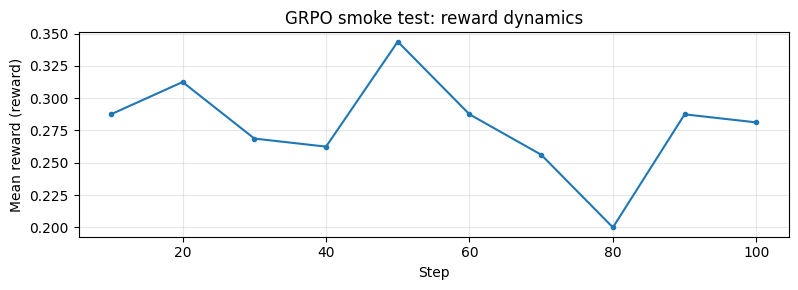

Reward: start=0.287, end=0.281


In [12]:
# Лог обучения
import json, os
import matplotlib.pyplot as plt

SMOKE_DIR = f'{GRPO_MODELS}/v500_smoke'

# Источник лога: переменная (если runtime жив) или файл на Drive
if 'smoke_grpo' in dir() and not smoke_grpo.get('skipped'):
    log = smoke_grpo['log']
elif os.path.exists(f'{SMOKE_DIR}/training_log.json'):
    with open(f'{SMOKE_DIR}/training_log.json') as f:
        log = json.load(f)
else:
    log = None
    print('Лог не найден')

if log:
    reward_key = None
    for key in ['reward', 'reward/mean', 'rewards/mean', 'train/reward']:
        if any(key in e for e in log):
            reward_key = key
            break

    if reward_key:
        reward_entries = [(e['step'], e[reward_key]) for e in log if reward_key in e]
        steps, rewards = zip(*reward_entries)
        plt.figure(figsize=(8, 3))
        plt.plot(steps, rewards, '-o', markersize=3)
        plt.xlabel('Step'); plt.ylabel(f'Mean reward ({reward_key})')
        plt.title('GRPO smoke test: reward dynamics')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(f'Reward: start={rewards[0]:.3f}, end={rewards[-1]:.3f}')
    else:
        print(f'Reward не найден. Ключи: {set(k for e in log for k in e.keys())}')

### 6.2 Оценка чекпоинтов smoke test

In [13]:
gc.collect(); torch.cuda.empty_cache()

engine = load_grpo_eval_engine(500)

smoke_eval = {}
for step in [50, 100]:
    ckpt_path = f'{SMOKE_DIR}/checkpoint-{step}'
    if not os.path.exists(ckpt_path):
        print(f'Чекпоинт {step} не найден, пропуск')
        continue
    print(f'\n── Checkpoint {step} ──')

    ckpt_name = f'v500_smoke_ckpt{step}'
    lora_path = f'{SMOKE_DIR}/checkpoint-{step}'
    gsm_resp = generate_cached_grpo(engine, 500, ckpt_name, 'gsm8k', GSM8K_PROBLEMS, lora_path)
    math_resp = generate_cached_grpo(engine, 500, ckpt_name, 'math500', MATH_PROBLEMS, lora_path)
    info = {
        'gsm8k': score_responses('gsm8k', gsm_resp),
        'math500': score_responses('math500', math_resp),
    }

    gsm, math = info['gsm8k'], info['math500']
    print(f'  GSM8K:    acc={gsm["accuracy"]:.3f} [{gsm["ci"][0]:.3f}, {gsm["ci"][1]:.3f}]  none_rate={gsm["none_rate"]:.1%}')
    print(f'  MATH-500: acc={math["accuracy"]:.3f} [{math["ci"][0]:.3f}, {math["ci"][1]:.3f}]  none_rate={math["none_rate"]:.1%}')
    smoke_eval[step] = info

del engine; gc.collect(); torch.cuda.empty_cache()

The tokenizer you are loading from '/content/drive/MyDrive/vkr_models/sft_merged/v500_best' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



── Checkpoint 50 ──


Rendering prompts:   0%|          | 0/1319 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

  [gsm8k] сгенерировано: 1319


...

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

  [gsm8k] сгенерировано: 1319


Rendering prompts:   0%|          | 0/500 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/500 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [math500] сгенерировано: 500
  GSM8K:    acc=0.406 [0.380, 0.431]  none_rate=36.5%
  MATH-500: acc=0.272 [0.232, 0.310]  none_rate=54.2%


### 6.3 Сравнение с SFT baseline

Ожидаемый эффект GRPO:
- none_rate должен снизиться (GRPO обучает модель останавливаться — arXiv:2505.07961)
- accuracy может вырасти, даже за 100 шагов

Если none_rate не снизился — проверить reward, KL, lr.

In [14]:
sft_name = best_sft[500]['run_name']
sft_path = f'{SFT_RESULTS}/{sft_name}.json'
if os.path.exists(sft_path):
    with open(sft_path) as f:
        sft_r = json.load(f)
    print(f'SFT  ({sft_name}):')
    print(f'  GSM8K={sft_r["gsm8k"]["accuracy"]:.3f}  none={sft_r["gsm8k"]["none_rate"]:.1%}')
    print(f'  MATH ={sft_r["math500"]["accuracy"]:.3f}  none={sft_r["math500"]["none_rate"]:.1%}')

    for step, info in sorted(smoke_eval.items()):
        print(f'\nGRPO (v500, step {step}):')
        print(f'  GSM8K={info["gsm8k"]["accuracy"]:.3f}  none={info["gsm8k"]["none_rate"]:.1%}')
        print(f'  MATH ={info["math500"]["accuracy"]:.3f}  none={info["math500"]["none_rate"]:.1%}')

SFT  (c2048_v500_s42):
  GSM8K=0.415  none=38.4%
  MATH =0.264  none=54.8%

GRPO (v500, step 50):
  GSM8K=0.415  none=36.5%
  MATH =0.240  none=55.0%

GRPO (v500, step 100):
  GSM8K=0.406  none=36.5%
  MATH =0.272  none=54.2%


##Unsloth

In [15]:
!pip install -q unsloth
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=f'{MERGED_DIR}/v500_best',
    max_seq_length=4096,
    dtype=torch.bfloat16,
    load_in_4bit=False,
    fast_inference=True,
)
print(f'Unsloth загружен ✓')
print(f'Model: {type(model).__name__}')

# Очистка — не держать в памяти
del model, tokenizer
import gc; gc.collect(); torch.cuda.empty_cache()
print('GPU освобождена')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.4/418.4 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 117.5 MB/s eta 0:00:00


/tmp/ipykernel_21811/412672509.py:2: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


ImportError: cannot import name 'truncate_dataset' from 'trl.data_utils' (/usr/local/lib/python3.12/dist-packages/trl/data_utils.py)

In [ ]:
Конфликт версий: Unsloth ставит свою версию TRL, которая несовместима с уже загруженной TRL 1.1.0. Unsloth должен импортироваться до trl/transformers/peft.
Для полного прогона нужен отдельный ноутбук с Unsloth с самого начала. Для MVP — работаем без него. Для полного прогона — отдельная сессия.

## Шаг 7. ═══ MIN ═══ Полный прогон: обучение

4 модели: v500 (2000 шагов), v1000 (500), v2000 (500), v5000 (2000).
Чекпоинты каждые 50 шагов. При обрыве Colab — resume с последнего чекпоинта.

In [ ]:
# Smoke test хранится в отдельной директории v500_smoke,
# боевая директория v500_best не затрагивается.
print('Smoke test изолирован от боевых прогонов ✓')

In [ ]:
gc.collect(); torch.cuda.empty_cache()
print(f'GPU свободно: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

In [ ]:
todo = [v for v in VOLUMES if v in best_sft and not is_grpo_complete(v)]
print(f'GRPO: всего {len(best_sft)}, готово {len(best_sft)-len(todo)}, осталось {len(todo)}')
for v in todo:
    resume = _find_latest_checkpoint(f'{GRPO_MODELS}/v{v}_best')
    status = f'resume с {os.path.basename(resume)}' if resume else 'с нуля'
    print(f'  v{v}: {GRPO_STEPS[v]} шагов, {status}')

In [ ]:
for i, volume in enumerate(todo):
    print(f'\n{"="*60}')
    print(f'[{i+1}/{len(todo)}] GRPO v{volume}  ({GRPO_STEPS[volume]} шагов)')
    print(f'{"="*60}')
    train_grpo(volume)

print('\nОбучение GRPO завершено')

## Шаг 8. ═══ MIN ═══ Оценка всех контрольных точек

Для каждого volume загружаем vLLM с merged моделью,
оцениваем все чекпоинты (каждые 50 шагов).
Кэш генераций: при обрыве Colab не перегенерируем.

In [ ]:
total_evals = 0
for v in best_sft:
    steps = get_checkpoint_steps(v)
    done = sum(1 for s in steps if os.path.exists(f'{GRPO_RESULTS}/v{v}_best_ckpt{s}.json'))
    total_evals += len(steps) - done
    print(f'v{v}: {len(steps)} чекпоинтов, {done} оценено, {len(steps)-done} осталось')
print(f'\nВсего eval: {total_evals}')

In [ ]:
for v in sorted(best_sft.keys()):
    steps = get_checkpoint_steps(v)
    todo_steps = [s for s in steps
                  if not os.path.exists(f'{GRPO_RESULTS}/v{v}_best_ckpt{s}.json')]
    if not todo_steps:
        print(f'v{v}: все чекпоинты оценены, пропуск')
        continue

    print(f'\n{"="*60}')
    print(f'v{v}: загрузка engine, оценка {len(todo_steps)} чекпоинтов')
    print(f'{"="*60}')

    engine = load_grpo_eval_engine(v)

    for i, step in enumerate(todo_steps):
        print(f'\n[{i+1}/{len(todo_steps)}] v{v} checkpoint-{step}')
        info = eval_grpo_checkpoint(engine, v, step)
        if info is None:
            continue

        gsm, math = info['gsm8k'], info['math500']
        print(f'  GSM8K={gsm["accuracy"]:.3f} [{gsm["ci"][0]:.3f},{gsm["ci"][1]:.3f}] none={gsm["none_rate"]:.1%}')
        print(f'  MATH ={math["accuracy"]:.3f} [{math["ci"][0]:.3f},{math["ci"][1]:.3f}] none={math["none_rate"]:.1%}')

        save_grpo_result(v, step, info)

    del engine; gc.collect(); torch.cuda.empty_cache()

print('\nОценка GRPO завершена')

## Шаг 9. Сводная таблица

Динамика по чекпоинтам: как accuracy и none_rate меняются по шагам GRPO.
Сравнение с SFT baseline.

In [ ]:
grpo_results = {}
for v in VOLUMES:
    for s in get_checkpoint_steps(v):
        path = f'{GRPO_RESULTS}/v{v}_best_ckpt{s}.json'
        if os.path.exists(path):
            with open(path) as f:
                grpo_results[f'v{v}_ckpt{s}'] = json.load(f)

print(f'GRPO-результатов: {len(grpo_results)}')

In [ ]:
print(f'{"volume":<8} {"step":<6} │ {"GSM8K acc":>10} {"none":>6} │ {"MATH acc":>10} {"none":>6}')
print('─' * 60)

for v in VOLUMES:
    # SFT baseline
    if v in best_sft:
        sft_name = best_sft[v]['run_name']
        sft_path = f'{SFT_RESULTS}/{sft_name}.json'
        if os.path.exists(sft_path):
            with open(sft_path) as f:
                r = json.load(f)
            print(f'v{v:<7} {"SFT":<6} │ {r["gsm8k"]["accuracy"]:>10.3f} {r["gsm8k"]["none_rate"]:>5.1%} │ '
                  f'{r["math500"]["accuracy"]:>10.3f} {r["math500"]["none_rate"]:>5.1%}')

    # GRPO: первый, каждый 200-й, последний
    steps = get_checkpoint_steps(v)
    show_steps = set()
    if steps:
        show_steps.add(steps[0])
        show_steps.add(steps[-1])
        show_steps.update(s for s in steps if s % 200 == 0)
    for s in sorted(show_steps):
        key = f'v{v}_ckpt{s}'
        if key in grpo_results:
            r = grpo_results[key]
            print(f'{"":8} {s:<6} │ {r["gsm8k"]["accuracy"]:>10.3f} {r["gsm8k"]["none_rate"]:>5.1%} │ '
                  f'{r["math500"]["accuracy"]:>10.3f} {r["math500"]["none_rate"]:>5.1%}')

    if v != VOLUMES[-1]:
        print()

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {500: 'C0', 1000: 'C1', 2000: 'C2', 5000: 'C3'}

for v in VOLUMES:
    steps_data = []
    for s in get_checkpoint_steps(v):
        key = f'v{v}_ckpt{s}'
        if key in grpo_results:
            steps_data.append((s, grpo_results[key]))

    if not steps_data:
        continue

    c = colors[v]
    x = [d[0] for d in steps_data]
    gsm_acc = [d[1]['gsm8k']['accuracy'] for d in steps_data]
    math_acc = [d[1]['math500']['accuracy'] for d in steps_data]

    axes[0].plot(x, gsm_acc, '-o', markersize=3, label=f'v{v}', color=c)
    axes[1].plot(x, math_acc, '-o', markersize=3, label=f'v{v}', color=c)

    # SFT baseline — тот же цвет, пунктир
    if v in best_sft:
        sft_path = f'{SFT_RESULTS}/{best_sft[v]["run_name"]}.json'
        if os.path.exists(sft_path):
            with open(sft_path) as f:
                sft_r = json.load(f)
            axes[0].axhline(sft_r['gsm8k']['accuracy'], color=c, ls='--', alpha=0.4)
            axes[1].axhline(sft_r['math500']['accuracy'], color=c, ls='--', alpha=0.4)

for ax, title in zip(axes, ['GSM8K', 'MATH-500']):
    ax.set_xlabel('GRPO step')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('GRPO: accuracy по шагам (пунктир — SFT baseline)')
plt.tight_layout()
plt.show()

In [ ]:
checks = []
for v in best_sft:
    checks.append((f'v{v} GRPO обучение', is_grpo_complete(v)))
    steps = get_checkpoint_steps(v)
    all_evaled = all(os.path.exists(f'{GRPO_RESULTS}/v{v}_best_ckpt{s}.json') for s in steps)
    checks.append((f'v{v} все чекпоинты оценены ({len(steps)} шт)', all_evaled))

ok = sum(c[1] for c in checks)
print(f'\nПроверка: {ok}/{len(checks)}')
for name, passed in checks:
    print(f'  {"✓" if passed else "✗"} {name}')

if ok == len(checks):
    print('\n✓ Этап GRPO завершён. Следующий шаг: 04_inference')